In [1]:
#Data manipulation and analysis libraries
import pandas as pd
import numpy as np 
#Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset and display the first few rows
df = pd.read_csv("data\Mobile_price_classification.csv")
display(df.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


EDA and data cleaning

In [13]:

# 1. Check dataset info and missing values
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
# Note: This Kaggle dataset is usually pre-cleaned and has 0 missing values!



<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

Train Test Split


In [4]:
# Separate features (X) and target (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1600, 20)
Testing data shape: (400, 20)


Implement Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier
# Initialize the model (using 100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)
# Make predictions
rf_preds = rf_model.predict(X_test)

In [6]:
# Evaluate Performance of Random Forest
print("=== Random Forest Performance ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, rf_preds))


=== Random Forest Performance ===
Accuracy: 0.8925

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       105
           1       0.89      0.87      0.88        91
           2       0.78      0.87      0.82        92
           3       0.94      0.87      0.90       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400



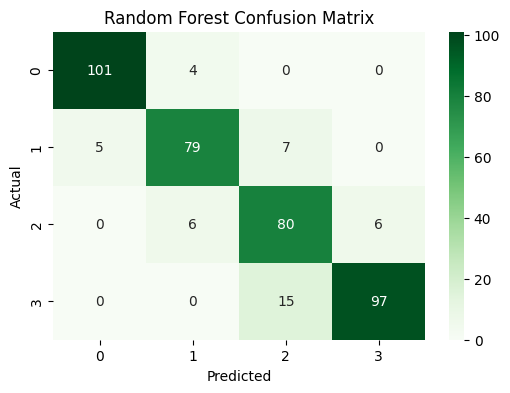

In [7]:
# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, cmap='Greens', fmt='g')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Feature Importance

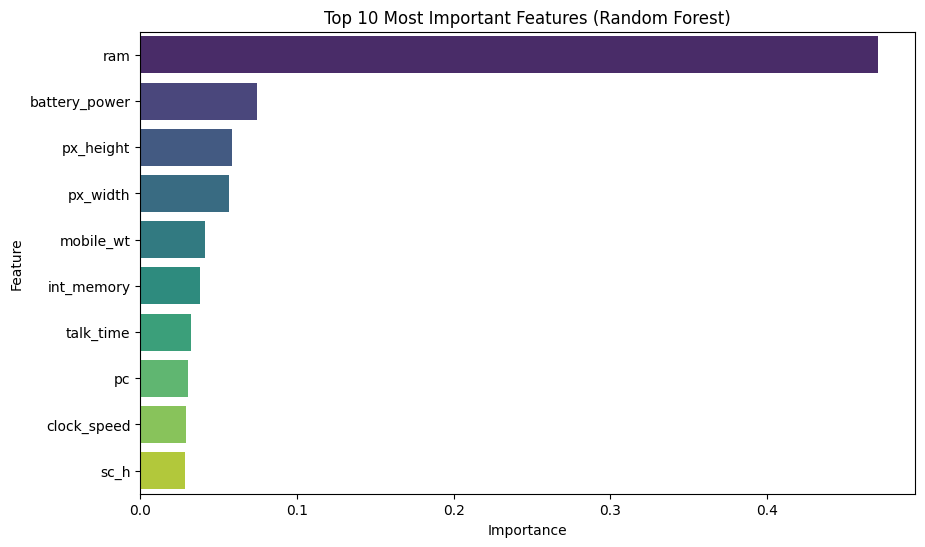

In [8]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.show()

Hyper Parameter Tuning

In [9]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # How deep each tree can go
    'min_samples_split': [2, 5, 10], # Minimum samples required to split a node
    'criterion': ['gini', 'entropy']  # How to measure the quality of a split
}

# 2. Initialize the Grid Search
# cv=5 means 5-fold Cross-Validation (standard industry practice)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, # Uses all your CPU cores for speed
                           verbose=1)

# 3. Run the search (this might take 30-60 seconds)
grid_search.fit(X_train, y_train)

# 4. Get the best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 5. Use the 'Best' model to make final predictions
best_rf = grid_search.best_estimator_
final_preds = best_rf.predict(X_test)

print(f"\nFinal Accuracy after Tuning: {accuracy_score(y_test, final_preds):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 0.8825

Final Accuracy after Tuning: 0.8975
